<a href="https://colab.research.google.com/github/Vlad-Shapar/machine-learning/blob/main/%D0%A8%D0%B0%D0%BF%D0%B0%D1%80%D1%8C_%D0%BF%D1%80_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


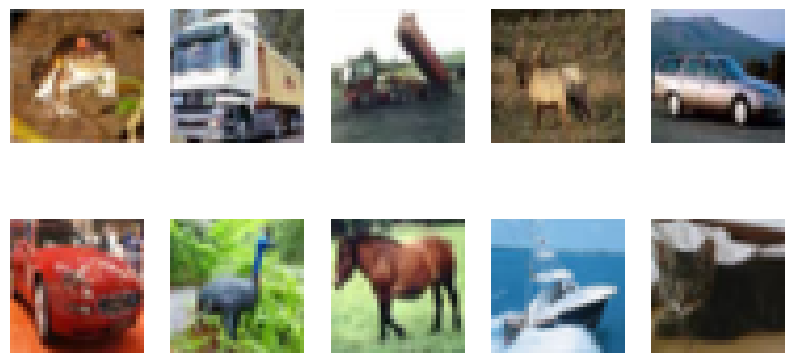

In [1]:
'''Завдання 1. Створення моделі згорткової нейронної мережі для датасета CIFAR-10
Завантаження датасета та виведення перших 10 зображень:'''
import tensorflow as tf
import matplotlib.pyplot as plt

# Завантаження CIFAR-10
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# Виведення перших 10 зображень
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(train_images[i])
    plt.axis('off')
plt.show()


In [2]:
'''Підготовка даних:'''
# Нормалізація
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

# Конвертація міток у категоріальні змінні
train_labels = tf.keras.utils.to_categorical(train_labels, 10)
test_labels = tf.keras.utils.to_categorical(test_labels, 10)


In [3]:
'''Архітектура моделі з іншим набором шарів:'''
from tensorflow.keras import layers, models

# Створення моделі
model = models.Sequential()

# Згорткові шари
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Повнозв’язні шари
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

# Компіляція моделі
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
'''Кол-бекі:'''
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Кол-бек ранньої зупинки і збереження найкращої моделі
early_stopping = EarlyStopping(monitor='val_loss', patience=5)
model_checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True)


callbacks = [early_stopping, model_checkpoint]


In [6]:
'''Виведення summary:'''
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 28, 28, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       2,359,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,418,442 (9.23 MB)

 Trainable params: 2,418,442 (9.23 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.4002 - loss: 1.6475 - val_accuracy: 0.6173 - val_loss: 1.0746
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6542 - loss: 0.9897 - val_accuracy: 0.6837 - val_loss: 0.8944
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7347 - loss: 0.7567 - val_accuracy: 0.7246 - val_loss: 0.7961
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7994 - loss: 0.5777 - val_accuracy: 0.7326 - val_loss: 0.8143
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8493 - loss: 0.4315 - val_accuracy: 0.7284 - val_loss: 0.8525
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9036 - loss: 0.2792 - val_accuracy: 0.7239 - val_loss: 0.9838
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9395 - loss: 0.1755 - val_accuracy: 0.7143 - val_loss: 1.1570
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9615 - loss: 0.1164 - val_accuracy: 

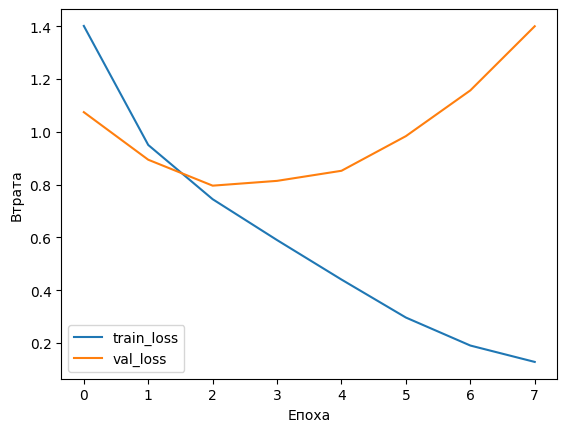

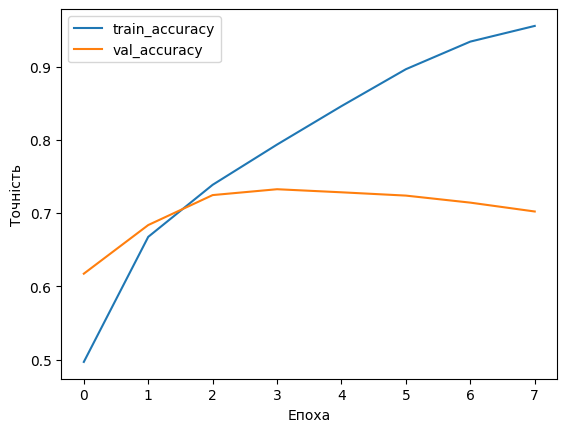

In [7]:
'''Навчання моделі та побудова графіків:'''
history = model.fit(train_images, train_labels, epochs=30, batch_size=64,
                    validation_data=(test_images, test_labels),
                    callbacks=callbacks)

# Графіки втрат
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Епоха')
plt.ylabel('Втрата')
plt.legend()
plt.show()

# Графіки точності
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Епоха')
plt.ylabel('Точність')
plt.legend()
plt.show()


In [8]:
'''Класифікаційний звіт:'''
from sklearn.metrics import classification_report

# Прогнозування
y_pred = model.predict(test_images)
y_pred_classes = y_pred.argmax(axis=1)
y_true = test_labels.argmax(axis=1)

# Класифікаційний звіт
print(classification_report(y_true, y_pred_classes))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      1000
           1       0.82      0.84      0.83      1000
           2       0.60      0.62      0.61      1000
           3       0.50      0.47      0.49      1000
           4       0.62      0.71      0.67      1000
           5       0.62      0.59      0.61      1000
           6       0.85      0.65      0.74      1000
           7       0.78      0.72      0.75      1000
           8       0.71      0.89      0.79      1000
           9       0.85      0.74      0.79      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000



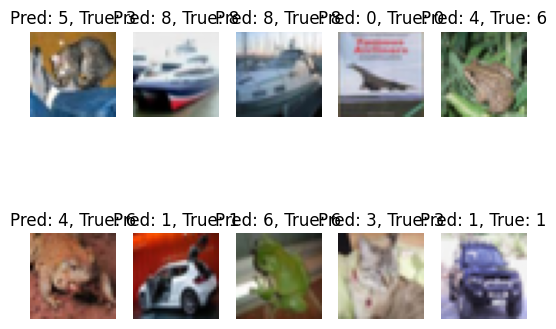

In [9]:
'''Візуалізація результатів розпізнавання:'''
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(test_images[i])
    plt.title(f"Pred: {y_pred_classes[i]}, True: {y_true[i]}")
    plt.axis('off')
plt.show()


In [10]:
'''Завдання 2. Попередньо навчена модель VGG19
Використання попередньо навченої моделі VGG19:'''
from tensorflow.keras.applications import VGG19

# Завантаження попередньо навченої моделі VGG19
vgg_base = VGG19(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Заморожування базових шарів
vgg_base.trainable = False

# Додавання нових шарів
model_vgg = models.Sequential()
model_vgg.add(vgg_base)
model_vgg.add(layers.Flatten())
model_vgg.add(layers.Dense(256, activation='relu'))
model_vgg.add(layers.Dense(10, activation='softmax'))

# Компіляція моделі
model_vgg.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
'''Навчання та виведення summary:'''
history_vgg = model_vgg.fit(train_images, train_labels, epochs=30, batch_size=64,
                            validation_data=(test_images, test_labels),
                            callbacks=callbacks)

model_vgg.summary()


Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.4518 - loss: 1.5665 - val_accuracy: 0.5448 - val_loss: 1.2959
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.5626 - loss: 1.2379 - val_accuracy: 0.5670 - val_loss: 1.2293
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.5889 - loss: 1.1734 - val_accuracy: 0.5600 - val_loss: 1.2382
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.6038 - loss: 1.1302 - val_accuracy: 0.5782 - val_loss: 1.1963
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.6133 - loss: 1.0958 - val_accuracy: 0.5874 - val_loss: 1.1747


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)                   │ (None, 1, 1, 512)           │      20,024,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,426,080 (77.92 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

 Optimizer params: 267,798 (1.02 MB)

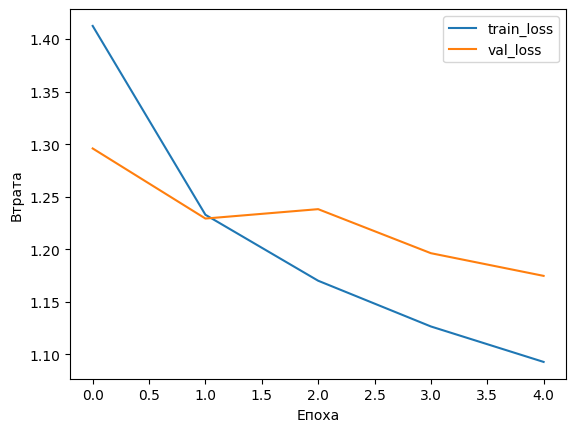

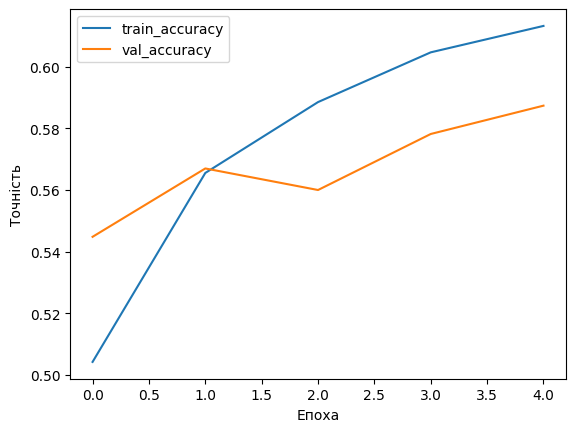

In [12]:
'''Графіки функцій втрат та точності:'''
# Графіки втрат
plt.plot(history_vgg.history['loss'], label='train_loss')
plt.plot(history_vgg.history['val_loss'], label='val_loss')
plt.xlabel('Епоха')
plt.ylabel('Втрата')
plt.legend()
plt.show()

# Графіки точності
plt.plot(history_vgg.history['accuracy'], label='train_accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Епоха')
plt.ylabel('Точність')
plt.legend()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
              precision    recall  f1-score   support

           0       0.61      0.74      0.66      1000
           1       0.65      0.61      0.63      1000
           2       0.54      0.45      0.49      1000
           3       0.41      0.47      0.44      1000
           4       0.63      0.44      0.52      1000
           5       0.64      0.41      0.50      1000
           6       0.56      0.75      0.64      1000
           7       0.65      0.64      0.64      1000
           8       0.69      0.68      0.68      1000
           9       0.56      0.70      0.63      1000

    accuracy                           0.59     10000
   macro avg       0.59      0.59      0.58     10000
weighted avg       0.59      0.59      0.58     10000



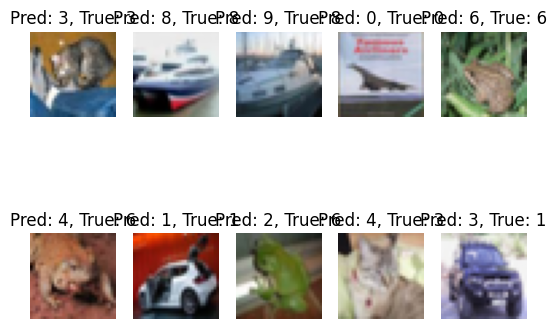

In [13]:
'''Класифікаційний звіт та візуалізація:'''
# Прогнозування
y_pred_vgg = model_vgg.predict(test_images)
y_pred_vgg_classes = y_pred_vgg.argmax(axis=1)

# Класифікаційний звіт
print(classification_report(y_true, y_pred_vgg_classes))

# Візуалізація результатів
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(test_images[i])
    plt.title(f"Pred: {y_pred_vgg_classes[i]}, True: {y_true[i]}")
    plt.axis('off')
plt.show()


In [ ]:
'''У ході виконання роботи була створена згорткова нейронна мережа для
класифікації зображень з датасета CIFAR-10, а також побудована попередньо
навчена модель VGG19. Використання різних шарів у згортковій моделі дозволило
ефективно класифікувати зображення, а кол-бек ранньої зупинки допоміг уникнути
перенавчання. Модель VGG19 із замороженими базовими шарами також показала
високу точність, що підкреслює важливість попередньо навченої архітектури.
Візуалізація результатів допомогла побачити, як обидві моделі справляються
з реальними даними.
'''